# Backtest XAUUSD 5m Strategy
Simulasi strategi robot berdasarkan data OHLC historis.

**Strategy:**
- H1 trend filter (EMA50/200 slope)
- M5 entry: EMA50 vs EMA200, RSI, candle pattern
- ATR filter >= 3.0, skip doji
- Score >= 5 dari 6
- SL = 1x ATR, TP = 2x ATR (RR 1:2)
- **Filter tambahan: RSI H1 norm >20, ADX H1 >= 32** → WR 54%+

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load & Prepare Data

In [2]:
df_raw = pd.read_csv('xauusd-ohcl.csv', sep='\t')
df_raw.columns = [c.strip('<>').lower() for c in df_raw.columns]
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.rename(columns={'tickvol': 'volume'})
df_raw = df_raw[['datetime','open','high','low','close','volume']].set_index('datetime')
df_raw = df_raw.sort_index()
print('Shape     :', df_raw.shape)
print('Date from :', df_raw.index[0])
print('Date to   :', df_raw.index[-1])
df_raw.head(3)

Shape     : (100000, 5)
Date from : 2024-11-29 12:40:00
Date to   : 2026-05-01 20:55:00


,open,high,low,close,volume
datetime,,,,,
2024-11-29 12:40:00,2661.515,2661.515,2659.207,2659.499,534
2024-11-29 12:45:00,2659.455,2660.325,2658.949,2659.971,531
2024-11-29 12:50:00,2659.983,2660.364,2658.996,2660.238,510


## 2. Hitung Indikator M5 & H1

In [3]:
df = df_raw.copy()
df['ema50_m5']  = ta.ema(df['close'], length=50)
df['ema200_m5'] = ta.ema(df['close'], length=200)
df['rsi_m5']    = ta.rsi(df['close'], length=14)
df['atr_m5']    = ta.atr(df['high'], df['low'], df['close'], length=14)

df_h1 = df_raw.resample('1h').agg({'open':'first','high':'max','low':'min','close':'last','volume':'sum'}).dropna()
df_h1['ema50_h1']  = ta.ema(df_h1['close'], length=50)
df_h1['ema200_h1'] = ta.ema(df_h1['close'], length=200)
df_h1['atr_h1']    = ta.atr(df_h1['high'], df_h1['low'], df_h1['close'], length=14)
df_h1['rsi_h1']    = ta.rsi(df_h1['close'], length=14)
df_h1['adx_h1']    = ta.adx(df_h1['high'], df_h1['low'], df_h1['close'])['ADX_14']
df_h1['slope_h1']  = df_h1['ema50_h1'] - df_h1['ema50_h1'].shift(4)

SLOPE_THRESHOLD = 0.25
def get_trend_h1(row):
    if row['slope_h1'] > SLOPE_THRESHOLD and (row['close'] > row['ema200_h1'] or row['ema50_h1'] > row['ema200_h1']):
        return 'up'
    elif row['slope_h1'] < -SLOPE_THRESHOLD and (row['close'] < row['ema200_h1'] or row['ema50_h1'] < row['ema200_h1']):
        return 'down'
    return 'sideways'

df_h1['trend_h1'] = df_h1.apply(get_trend_h1, axis=1)
df_h1_m5 = df_h1[['ema50_h1','ema200_h1','atr_h1','trend_h1','rsi_h1','adx_h1']].resample('5min').ffill()
df = df.join(df_h1_m5, how='left')
df[['ema50_h1','ema200_h1','atr_h1','trend_h1','rsi_h1','adx_h1']] = df[['ema50_h1','ema200_h1','atr_h1','trend_h1','rsi_h1','adx_h1']].ffill()
print('Indikator selesai')
df[['close','ema50_m5','ema200_m5','rsi_m5','atr_m5','trend_h1','rsi_h1','adx_h1']].tail(3)

Indikator selesai


,close,ema50_m5,ema200_m5,rsi_m5,atr_m5,trend_h1,rsi_h1,adx_h1
datetime,,,,,,,,
2026-05-01 20:45:00,4613.199,4619.772494,4613.478937,42.997420,3.871979,sideways,51.58279,21.415153
2026-05-01 20:50:00,4616.276,4619.635377,4613.506769,49.281972,3.887695,sideways,51.58279,21.415153
2026-05-01 20:55:00,4613.396,4619.390695,4613.505667,44.353039,3.903860,sideways,51.58279,21.415153


## 3. Deteksi Candle Pattern

In [4]:
def detect_pattern(df, i):
    if i < 1: return 'none'
    o,h,l,c   = df['open'].iloc[i],df['high'].iloc[i],df['low'].iloc[i],df['close'].iloc[i]
    po,pc     = df['open'].iloc[i-1],df['close'].iloc[i-1]
    body=abs(c-o); up_shad=h-max(o,c); lo_shad=min(o,c)-l; cr=h-l; mid=(h+l)/2
    if cr==0: return 'none'
    if body < cr*0.05: return 'doji'
    if lo_shad>2*body and lo_shad>up_shad and c>mid: return 'pin_bar_bull'
    if up_shad>2*body and up_shad>lo_shad and c<mid: return 'pin_bar_bear'
    if c>o and pc<po and c>po and o<pc: return 'engulfing_bull'
    if c<o and pc>po and c<po and o>pc: return 'engulfing_bear'
    if c>o and body>=cr*0.8: return 'marubozu_bull'
    if c<o and body>=cr*0.8: return 'marubozu_bear'
    return 'none'

df['pattern'] = [detect_pattern(df,i) for i in range(len(df))]
print('Pattern distribution:')
print(df['pattern'].value_counts())

Pattern distribution:
pattern
none              53856
pin_bar_bull      11518
pin_bar_bear      10115
engulfing_bull     5527
engulfing_bear     5408
doji               5233
marubozu_bull      4545
marubozu_bear      3798
Name: count, dtype: int64


## 4. Hitung Confluence Score

In [5]:
def calc_score(row, action):
    if action == 'buy':
        if row['trend_h1'] != 'up': return 0
        s = 1
        if row['ema50_m5'] > row['ema200_m5']: s += 1
        if row['rsi_m5'] > 50: s += 1
        if row['pattern'] in ('pin_bar_bull','engulfing_bull','marubozu_bull'): s += 1
        if row['close'] < row['ema50_h1']: s += 1
        if row['close'] > row['ema200_h1']: s += 1
        return s
    elif action == 'sell':
        if row['trend_h1'] != 'down': return 0
        s = 1
        if row['ema50_m5'] < row['ema200_m5']: s += 1
        if row['rsi_m5'] < 50: s += 1
        if row['pattern'] in ('pin_bar_bear','engulfing_bear','marubozu_bear'): s += 1
        if row['close'] > row['ema50_h1']: s += 1
        if row['close'] < row['ema200_h1']: s += 1
        return s
    return 0

df['score_buy']  = df.apply(lambda r: calc_score(r,'buy'),  axis=1)
df['score_sell'] = df.apply(lambda r: calc_score(r,'sell'), axis=1)
print('Score buy :', df['score_buy'].value_counts().sort_index().to_dict())
print('Score sell:', df['score_sell'].value_counts().sort_index().to_dict())

Score buy : {0: 48718, 1: 4, 2: 2459, 3: 17159, 4: 24981, 5: 6678, 6: 1}
Score sell: {0: 74582, 1: 32, 2: 1835, 3: 9334, 4: 11425, 5: 2791, 6: 1}


## 5. Generate Signal & Simulasi Order

In [6]:
ATR_MIN   = 3.0
SCORE_MIN = 5
LOT       = 0.01
trades = []
trade_id = 1

df_valid = df.dropna(subset=['ema50_m5','ema200_m5','rsi_m5','atr_m5','ema50_h1','ema200_h1','rsi_h1','adx_h1'])

for i in range(1, len(df_valid)):
    row = df_valid.iloc[i]
    if row['atr_m5'] < ATR_MIN: continue
    if row['pattern'] == 'doji': continue
    action = None; score = 0
    if row['score_buy'] >= SCORE_MIN:    action='buy';  score=int(row['score_buy'])
    elif row['score_sell'] >= SCORE_MIN: action='sell'; score=int(row['score_sell'])
    if action is None: continue

    o_val=row['open']; h_val=row['high']; l_val=row['low']; c_val=row['close']
    body=round(abs(c_val-o_val),4); upper_shadow=round(h_val-max(o_val,c_val),4)
    lower_shadow=round(min(o_val,c_val)-l_val,4); cr=h_val-l_val
    candle_dir = 'doji' if (cr>0 and body<cr*0.05) else ('bullish' if c_val>o_val else 'bearish')

    entry=round(c_val,2); atr=row['atr_m5']
    sl = round(entry-atr   if action=='buy' else entry+atr,   2)
    tp = round(entry+2*atr if action=='buy' else entry-2*atr, 2)

    outcome='open'; close_price=None; close_time=None
    for j,frow in df_valid.iloc[i+1:i+200].iterrows():
        if action=='buy':
            if frow['low']<=sl:  outcome='loss';   close_price=sl; close_time=j; break
            if frow['high']>=tp: outcome='profit'; close_price=tp; close_time=j; break
        else:
            if frow['high']>=sl: outcome='loss';   close_price=sl; close_time=j; break
            if frow['low']<=tp:  outcome='profit'; close_price=tp; close_time=j; break
    if outcome=='open': continue

    profit=round((close_price-entry)*(1 if action=='buy' else -1)*LOT*100,2)
    in_support    = bool(c_val<=row['ema50_h1'] and c_val>=row['ema200_h1'])
    in_resistance = bool(c_val>=row['ema50_h1'] and c_val<=row['ema200_h1'])
    has_bull = row['pattern'] in ('pin_bar_bull','engulfing_bull','marubozu_bull')
    has_bear = row['pattern'] in ('pin_bar_bear','engulfing_bear','marubozu_bear')

    trades.append({
        'id':trade_id,'signal_id':trade_id,'symbol':'XAUUSDm','action':action,
        'lot':LOT,'price':entry,'sl':sl,'tp':tp,'ticket':None,'status':'closed',
        'close_price':round(close_price,2),'profit':profit,'outcome':outcome,
        'comment':'backtest','created_by':'backtest','closed_at':close_time,
        'entry_target':None,'expire_at':None,'candle_id':trade_id,
        'signal_symbol':'XAUUSDm','signal':action,'signal_sl':sl,'tp1':tp,
        'trend_h1':row['trend_h1'],'ema_50_h1':round(row['ema50_h1'],2),
        'ema_200_h1':round(row['ema200_h1'],2),'in_support':in_support,
        'in_resistance':in_resistance,'atr_h1':round(row['atr_h1'],4),
        'open_m5':round(o_val,2),'high_m5':round(h_val,2),'low_m5':round(l_val,2),
        'close_m5':round(c_val,2),'volume_m5':round(row['volume'],2),
        'ema_50_m5':round(row['ema50_m5'],2),'ema_200_m5':round(row['ema200_m5'],2),
        'rsi_m5':round(row['rsi_m5'],2),'atr_m5':round(atr,4),
        'has_bull_pattern':has_bull,'has_bear_pattern':has_bear,'signal_score':score,
        'rsi_h1':round(row['rsi_h1'],2),'adx_h1':round(row['adx_h1'],2),
        'candle_symbol':'XAUUSDm','timeframe':'M5','candle_time':df_valid.index[i],
        'open':round(o_val,2),'high':round(h_val,2),'low':round(l_val,2),
        'close':round(c_val,2),'volume':round(row['volume'],2),
        'body':body,'upper_shadow':upper_shadow,'lower_shadow':lower_shadow,
        'candle_dir':candle_dir,'pattern_name':row['pattern'],
        'candle_trend_h1':row['trend_h1'],'candle_in_support':in_support,
        'candle_in_resistance':in_resistance,'pattern_score':score,'pattern_outcome':outcome,
    })
    trade_id += 1

trades_df = pd.DataFrame(trades)
print(f'Total signal : {len(trades_df)}')
print(f'Profit       : {len(trades_df[trades_df["outcome"]=="profit"])}')
print(f'Loss         : {len(trades_df[trades_df["outcome"]=="loss"])}')
trades_df.head(3)

Total signal : 5336
Profit       : 1835
Loss         : 3501


,id,signal_id,symbol,action,lot,price,sl,tp,ticket,status,...,body,upper_shadow,lower_shadow,candle_dir,pattern_name,candle_trend_h1,candle_in_support,candle_in_resistance,pattern_score,pattern_outcome
0,1,1,XAUUSDm,sell,0.01,2618.30,2622.30,2610.31,None,closed,...,1.624,4.488,0.798,bullish,pin_bar_bear,down,False,False,5,profit
1,2,2,XAUUSDm,sell,0.01,2610.07,2614.43,2601.35,None,closed,...,8.258,0.389,0.462,bearish,engulfing_bear,down,False,False,5,profit
2,3,3,XAUUSDm,sell,0.01,2608.50,2612.93,2599.64,None,closed,...,1.623,3.250,0.422,bearish,pin_bar_bear,down,False,False,5,profit


## 6. Equity Curve

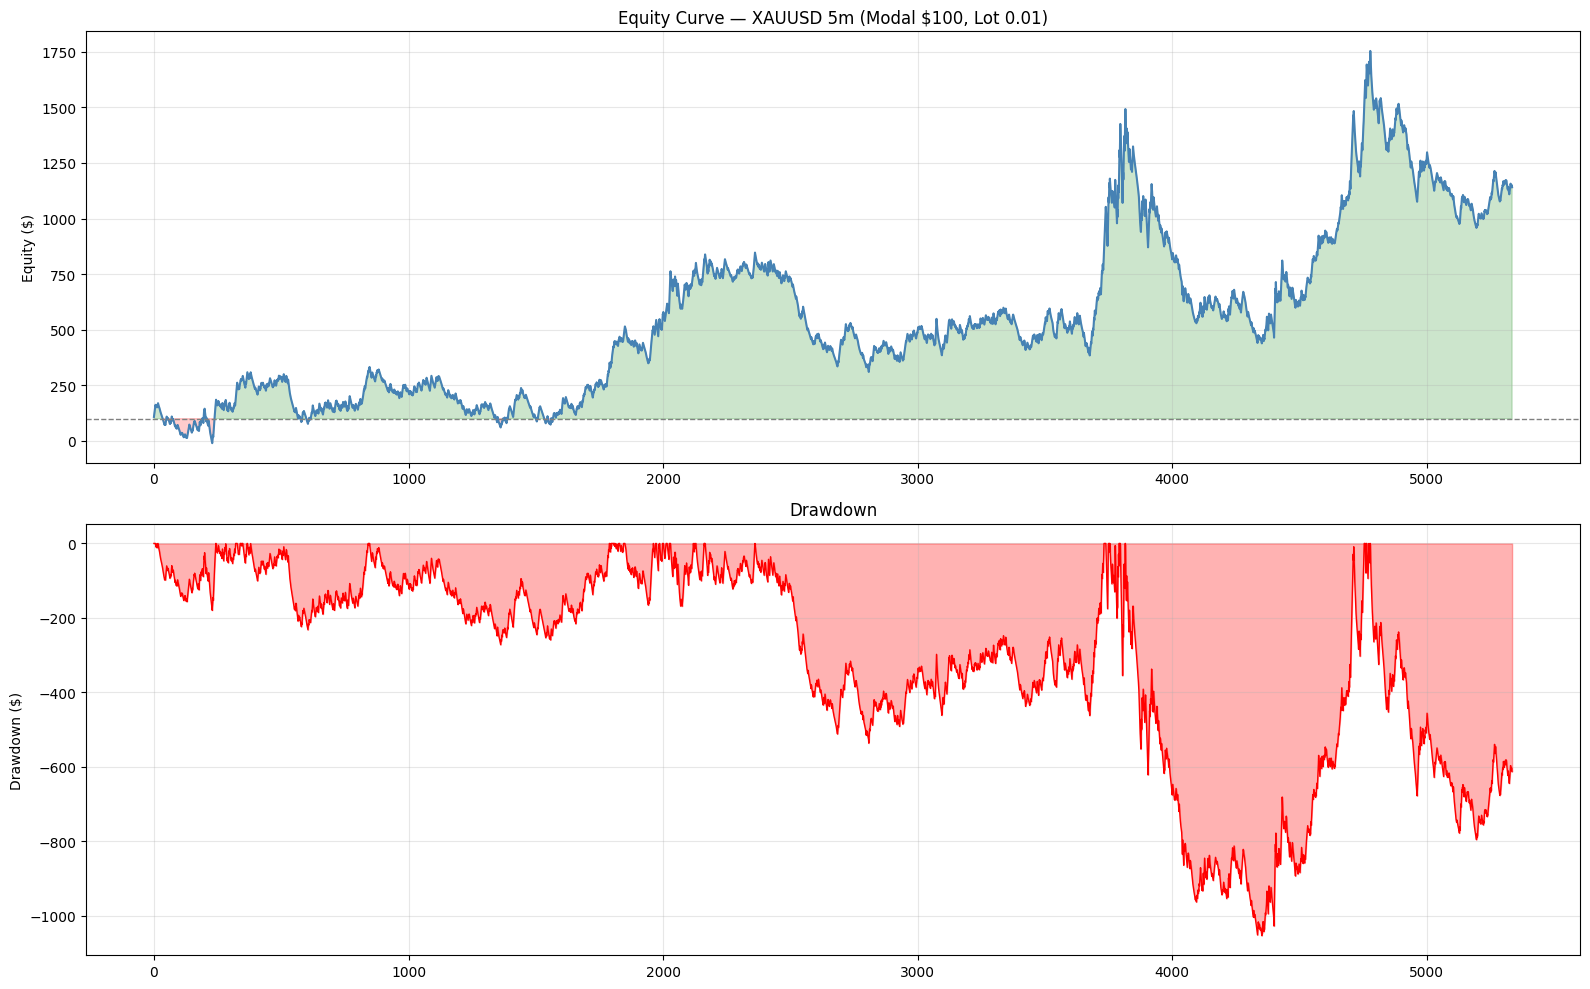

In [7]:
t = trades_df
equity   = 100 + t['profit'].cumsum()
drawdown = equity - equity.cummax()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
equity.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].axhline(100, color='gray', linestyle='--', linewidth=1)
axes[0].fill_between(equity.index, 100, equity, where=equity>=100, alpha=0.2, color='green')
axes[0].fill_between(equity.index, 100, equity, where=equity<100,  alpha=0.2, color='red')
axes[0].set_title('Equity Curve — XAUUSD 5m (Modal $100, Lot 0.01)')
axes[0].set_ylabel('Equity ($)')
drawdown.plot(ax=axes[1], color='red', linewidth=1)
axes[1].fill_between(drawdown.index, drawdown, 0, alpha=0.3, color='red')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown ($)')
plt.tight_layout()
plt.show()

## 7. Analisa WR per Score & Pattern

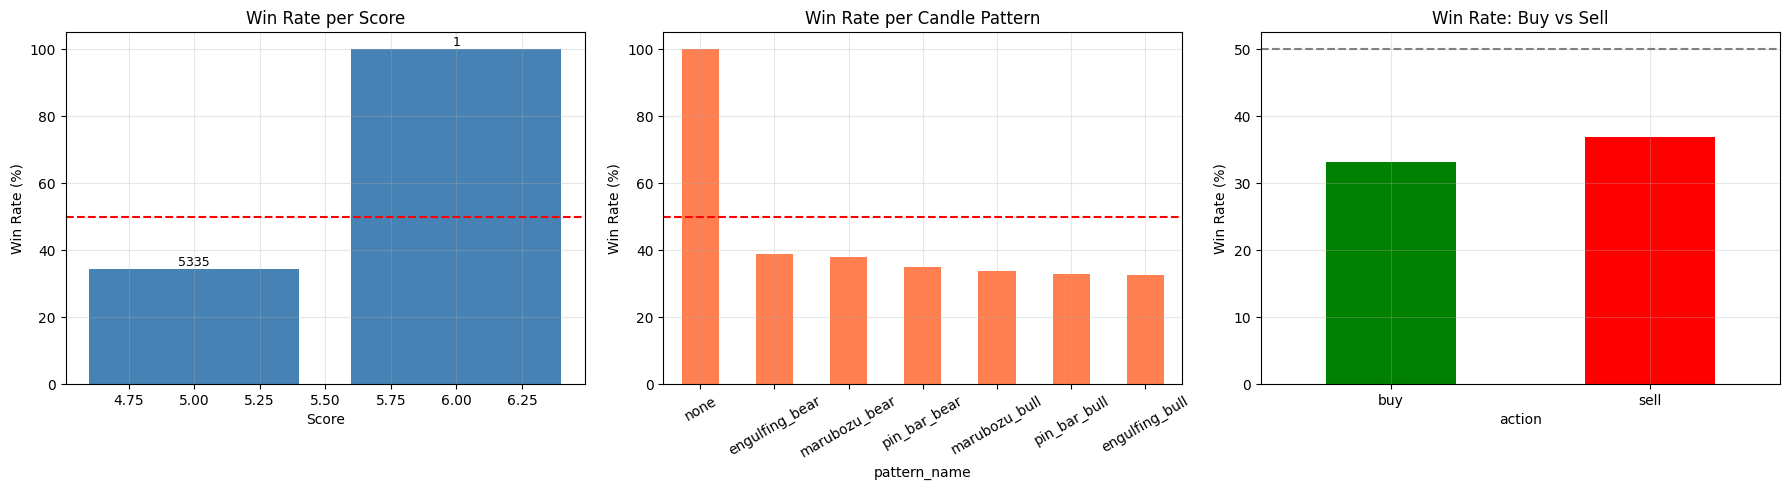

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

score_stats = t.groupby('signal_score').agg(
    count=('outcome', 'count'),
    wr=('outcome', lambda x: (x=='profit').mean()*100)
).reset_index().rename(columns={'signal_score': 'score'})

axes[0].bar(score_stats['score'], score_stats['wr'], color='steelblue')
axes[0].axhline(50, color='red', linestyle='--')
axes[0].set_title('Win Rate per Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Win Rate (%)')
for _, row in score_stats.iterrows():
    axes[0].text(row['score'], row['wr']+1, f"{int(row['count'])}", ha='center', fontsize=9)

pat_stats = t.groupby('pattern_name').agg(
    wr=('outcome', lambda x: (x=='profit').mean()*100)
).sort_values('wr', ascending=False)
pat_stats['wr'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].axhline(50, color='red', linestyle='--')
axes[1].set_title('Win Rate per Candle Pattern')
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

act_stats = t.groupby('action').agg(
    wr=('outcome', lambda x: (x=='profit').mean()*100)
)
act_stats['wr'].plot(kind='bar', ax=axes[2], color=['green','red'])
axes[2].axhline(50, color='gray', linestyle='--')
axes[2].set_title('Win Rate: Buy vs Sell')
axes[2].set_ylabel('Win Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 8. Filter Jam UTC — Skip Jam Buruk

  JAM FILTER: skip jam [10, 11, 16, 17] UTC
                               Sebelum      Sesudah
  Total Trade                     5336         4402
  Win Rate                       34.4%        36.2%
  Net P&L                 $    1040.63 $    1990.46
  Max Drawdown            $   -1053.30 $    -735.99
  Equity Akhir            $    1140.63 $    2090.46

Detail WR per jam UTC:
 hour  total        wr    avg_pl
    0    206 32.038835 -1.449903
    1    254 36.220472 -0.143228
    2    252 34.920635  1.250595
    3    246 32.926829  0.046911
    4    184 39.130435  0.593967
    5    218 40.825688  1.589037
    6    209 41.148325  0.787560
    7    204 34.313725 -0.012500
    8    186 33.870968 -0.177204
    9    203 29.064039 -0.303202
   10    193 25.906736 -1.062073
   11    189 28.042328 -0.610582
   12    219 30.136986 -0.185571
   13    310 34.193548  0.150839
   14    372 38.709677  1.118226
   15    364 36.813187  0.303077
   16    300 28.000000 -0.932500
   17    252 21.428571 -1.

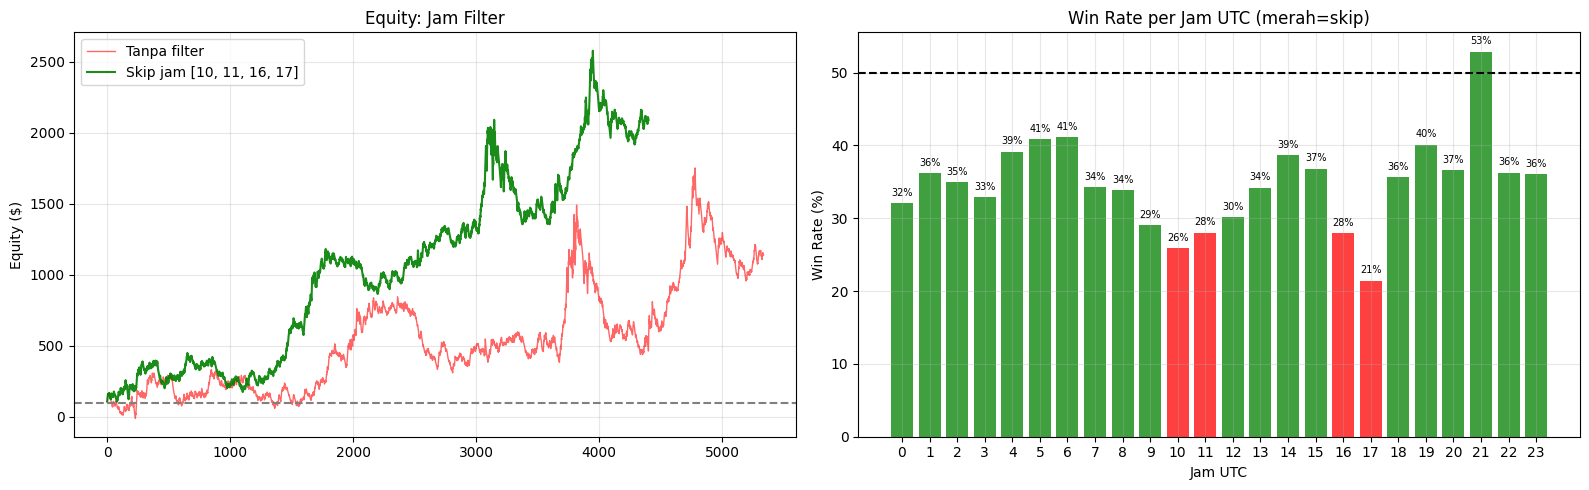

In [9]:
BAD_HOURS = [10, 11, 16, 17]

t_orig = trades_df.copy()
t_orig['hour'] = pd.to_datetime(t_orig['candle_time']).dt.hour

eq_b = 100 + t_orig['profit'].cumsum()
t_jam = t_orig[~t_orig['hour'].isin(BAD_HOURS)].copy()
eq_a  = 100 + t_jam['profit'].reset_index(drop=True).cumsum()

hour_wr = t_orig.groupby('hour').agg(
    total=('outcome','count'),
    wr=('outcome', lambda x: (x=='profit').mean()*100),
    avg_pl=('profit','mean')
).reset_index()

wr_b = (t_orig['outcome']=='profit').mean()*100
wr_a = (t_jam['outcome']=='profit').mean()*100

print('=' * 55)
print(f'  JAM FILTER: skip jam {BAD_HOURS} UTC')
print('=' * 55)
print(f"{'':25} {'Sebelum':>12} {'Sesudah':>12}")
print(f"  {'Total Trade':<23} {len(t_orig):>12} {len(t_jam):>12}")
print(f"  {'Win Rate':<23} {wr_b:>11.1f}% {wr_a:>11.1f}%")
print(f"  {'Net P&L':<23} ${t_orig['profit'].sum():>11.2f} ${t_jam['profit'].sum():>11.2f}")
print(f"  {'Max Drawdown':<23} ${(eq_b-eq_b.cummax()).min():>11.2f} ${(eq_a-eq_a.cummax()).min():>11.2f}")
print(f"  {'Equity Akhir':<23} ${eq_b.iloc[-1]:>11.2f} ${eq_a.iloc[-1]:>11.2f}")
print('=' * 55)

print('\nDetail WR per jam UTC:')
print(hour_wr.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
eq_b.reset_index(drop=True).plot(ax=axes[0], color='red',   label='Tanpa filter', alpha=0.6, linewidth=1)
eq_a.plot(ax=axes[0], color='green', label=f'Skip jam {BAD_HOURS}', alpha=0.9, linewidth=1.5)
axes[0].axhline(100, color='gray', linestyle='--')
axes[0].set_title('Equity: Jam Filter')
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
colors = ['green' if h not in BAD_HOURS else 'red' for h in hour_wr['hour']]
axes[1].bar(hour_wr['hour'], hour_wr['wr'], color=colors, alpha=0.75)
axes[1].axhline(50, color='black', linestyle='--')
axes[1].set_title('Win Rate per Jam UTC (merah=skip)')
axes[1].set_xlabel('Jam UTC')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xticks(range(24))
for _, row in hour_wr.iterrows():
    axes[1].text(row['hour'], row['wr']+1, f"{row['wr']:.0f}%", ha='center', fontsize=7)
plt.tight_layout()
plt.show()

## 9. Filter BB Width — Skip Volatilitas Ekstrem

WR per BB Width:
        bbw_cat  total        wr     avg_pl  net_pl
 1-2% (optimal)    618 36.731392   1.472945  910.28
2-3% (moderate)    129 33.333333   0.838062  108.11
3-5% (volatile)     44 27.272727  -3.866136 -170.11
 < 1% (squeeze)   4538 34.222124   0.099835  453.05
 > 5% (extreme)      7  0.000000 -37.242857 -260.70

  BBW FILTER: hanya BBW 1.0% - 3.0%
                               Sebelum      Sesudah
  Total Trade                     5336          747
  Win Rate                       34.4%        36.1%
  Net P&L                 $    1040.63 $    1018.39
  Max Drawdown            $   -1053.30 $    -445.49
  Equity Akhir            $    1140.63 $    1118.39


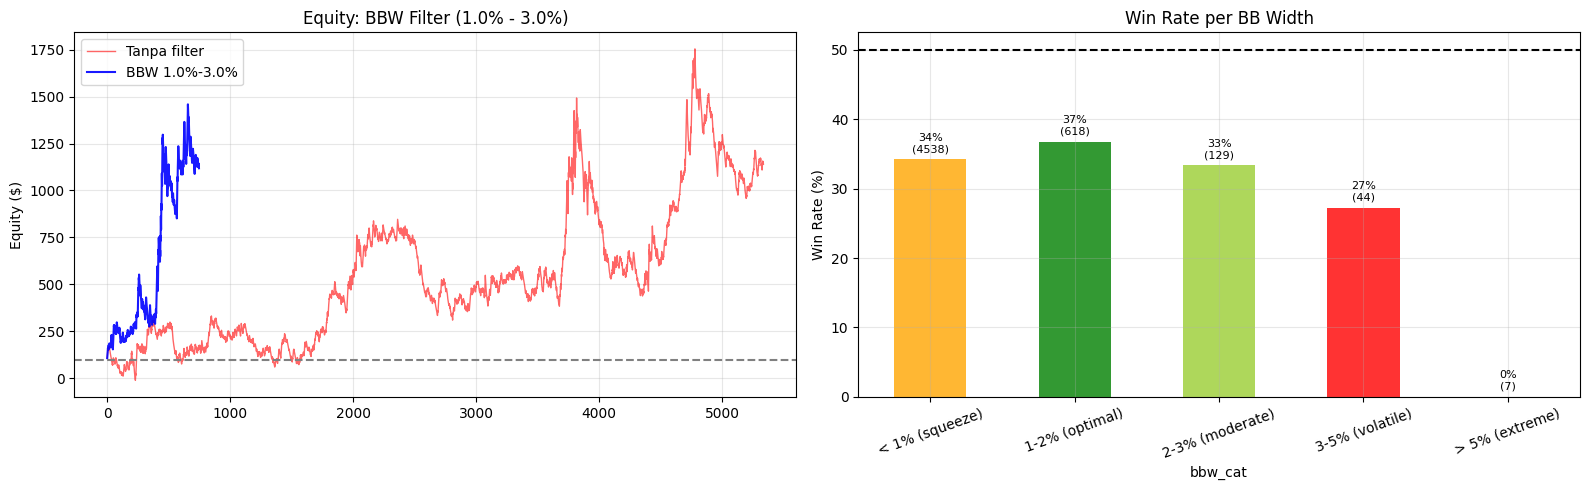

In [10]:
bb = ta.bbands(df['close'], length=20, std=2)
bbu_col = [c for c in bb.columns if c.startswith('BBU')][0]
bbl_col = [c for c in bb.columns if c.startswith('BBL')][0]
bbm_col = [c for c in bb.columns if c.startswith('BBM')][0]
df['bbw'] = (bb[bbu_col] - bb[bbl_col]) / bb[bbm_col] * 100

t_bbw = trades_df.copy()
t_bbw['bbw'] = pd.to_datetime(t_bbw['candle_time']).map(df['bbw'].to_dict())

def bbw_cat(w):
    if pd.isna(w):  return 'unknown'
    if w < 1.0:     return '< 1% (squeeze)'
    if w < 2.0:     return '1-2% (optimal)'
    if w < 3.0:     return '2-3% (moderate)'
    if w < 5.0:     return '3-5% (volatile)'
    return '> 5% (extreme)'

t_bbw['bbw_cat'] = t_bbw['bbw'].apply(bbw_cat)

bbw_stats = t_bbw.groupby('bbw_cat').agg(
    total=('outcome','count'),
    wr=('outcome', lambda x: (x=='profit').mean()*100),
    avg_pl=('profit','mean'),
    net_pl=('profit','sum')
).reset_index().sort_values('bbw_cat')
print('WR per BB Width:')
print(bbw_stats.to_string(index=False))

BBW_MIN = 1.0; BBW_MAX = 3.0
t_bb_filtered = t_bbw[(t_bbw['bbw'] >= BBW_MIN) & (t_bbw['bbw'] < BBW_MAX)].copy()

eq_b2 = 100 + t_bbw['profit'].cumsum()
eq_a2 = 100 + t_bb_filtered['profit'].reset_index(drop=True).cumsum()
wr_b2 = (t_bbw['outcome']=='profit').mean()*100
wr_a2 = (t_bb_filtered['outcome']=='profit').mean()*100

print('\n' + '=' * 55)
print(f'  BBW FILTER: hanya BBW {BBW_MIN}% - {BBW_MAX}%')
print('=' * 55)
print(f"{'':25} {'Sebelum':>12} {'Sesudah':>12}")
print(f"  {'Total Trade':<23} {len(t_bbw):>12} {len(t_bb_filtered):>12}")
print(f"  {'Win Rate':<23} {wr_b2:>11.1f}% {wr_a2:>11.1f}%")
print(f"  {'Net P&L':<23} ${t_bbw['profit'].sum():>11.2f} ${t_bb_filtered['profit'].sum():>11.2f}")
print(f"  {'Max Drawdown':<23} ${(eq_b2-eq_b2.cummax()).min():>11.2f} ${(eq_a2-eq_a2.cummax()).min():>11.2f}")
print(f"  {'Equity Akhir':<23} ${eq_b2.iloc[-1]:>11.2f} ${eq_a2.iloc[-1]:>11.2f}")
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
eq_b2.reset_index(drop=True).plot(ax=axes[0], color='red',  label='Tanpa filter', alpha=0.6, linewidth=1)
eq_a2.plot(ax=axes[0], color='blue', label=f'BBW {BBW_MIN}%-{BBW_MAX}%', alpha=0.9, linewidth=1.5)
axes[0].axhline(100, color='gray', linestyle='--')
axes[0].set_title(f'Equity: BBW Filter ({BBW_MIN}% - {BBW_MAX}%)')
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
cats_all  = ['< 1% (squeeze)','1-2% (optimal)','2-3% (moderate)','3-5% (volatile)','> 5% (extreme)']
cats_pres = [c for c in cats_all if c in bbw_stats['bbw_cat'].values]
bbw_plot  = bbw_stats.set_index('bbw_cat').reindex(cats_pres)
bar_colors = ['orange','green','yellowgreen','red','darkred'][:len(bbw_plot)]
bbw_plot['wr'].plot(kind='bar', ax=axes[1], color=bar_colors, alpha=0.8)
axes[1].axhline(50, color='black', linestyle='--')
axes[1].set_title('Win Rate per BB Width')
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
for i, (_, row) in enumerate(bbw_plot.iterrows()):
    axes[1].text(i, row['wr']+1, f"{row['wr']:.0f}%\n({int(row['total'])})", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Combined Filter — Jam + BB Width

  PERBANDINGAN SEMUA FILTER
                          Original     Jam UTC         BBW    Combined
--------------------------------------------------------------------
  Total Trade                 5336        4402         747         641
  Win Rate                   34.4%       36.2%       36.1%       36.8%
  Net P&L              $   1040.63 $   1990.46 $   1018.39 $    987.71
  Max Drawdown         $  -1053.30 $   -735.99 $   -445.49 $   -391.38
  Equity Akhir         $   1140.63 $   2090.46 $   1118.39 $   1087.71

  Max Loss Streak (combined) : 14x berturut-turut
  Modal AMAN   (equity terendah = $107.99)


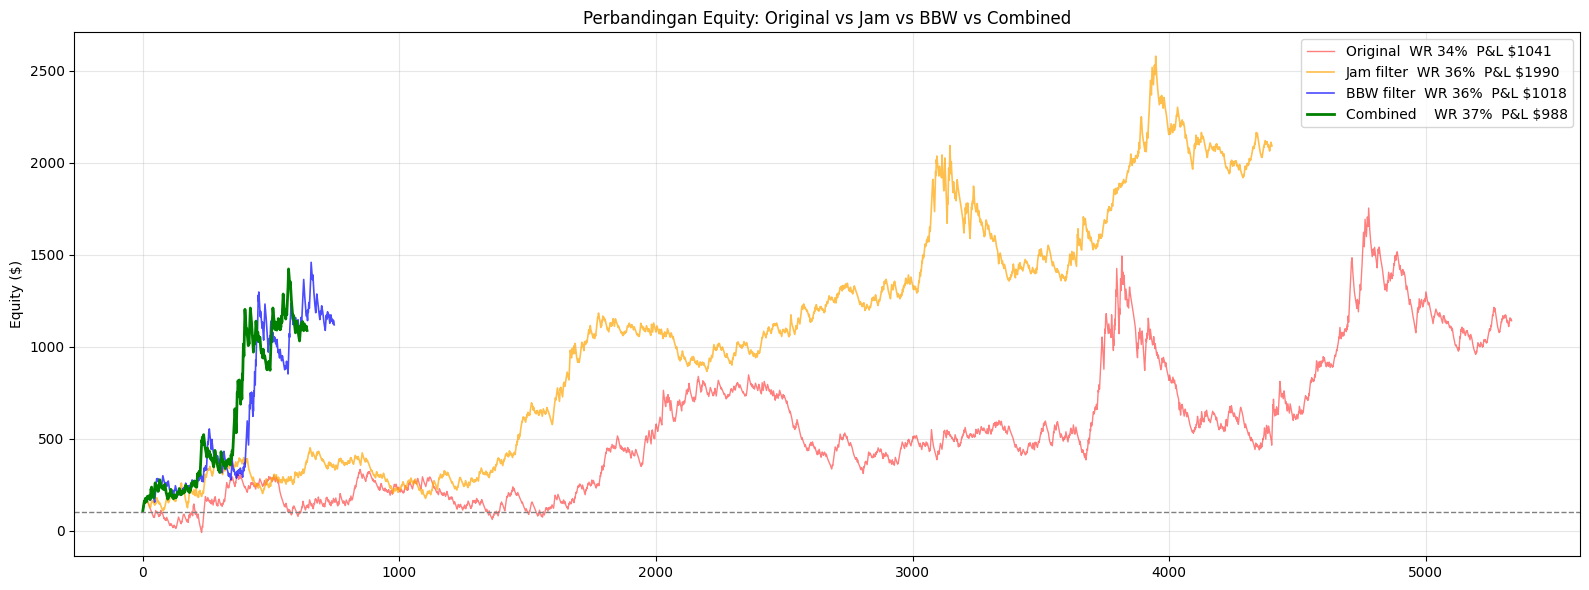

In [11]:
BAD_HOURS_F = [10, 11, 16, 17]
BBW_MIN_F   = 1.0
BBW_MAX_F   = 3.0

t_combined = t_bbw.copy()
t_combined['hour'] = pd.to_datetime(t_combined['candle_time']).dt.hour
t_cf = t_combined[
    (~t_combined['hour'].isin(BAD_HOURS_F)) &
    (t_combined['bbw'] >= BBW_MIN_F) &
    (t_combined['bbw'] <  BBW_MAX_F)
].copy()

def calc_stats(tdf):
    n = len(tdf)
    if n == 0: return dict(total=0, wr=0.0, pl=0.0, dd=0.0, eq=100.0)
    w  = (tdf['outcome']=='profit').sum()
    pl = tdf['profit'].sum()
    eq = 100 + tdf['profit'].reset_index(drop=True).cumsum()
    dd = (eq - eq.cummax()).min()
    return dict(total=n, wr=w/n*100, pl=pl, dd=dd, eq=eq.iloc[-1])

s_orig = calc_stats(trades_df)
s_jam  = calc_stats(t_jam)
s_bbw  = calc_stats(t_bb_filtered)
s_comb = calc_stats(t_cf)

print('=' * 68)
print('  PERBANDINGAN SEMUA FILTER')
print('=' * 68)
print(f"{'':22} {'Original':>11} {'Jam UTC':>11} {'BBW':>11} {'Combined':>11}")
print('-' * 68)
print(f"  {'Total Trade':<20} {s_orig['total']:>11} {s_jam['total']:>11} {s_bbw['total']:>11} {s_comb['total']:>11}")
print(f"  {'Win Rate':<20} {s_orig['wr']:>10.1f}% {s_jam['wr']:>10.1f}% {s_bbw['wr']:>10.1f}% {s_comb['wr']:>10.1f}%")
print(f"  {'Net P&L':<20} ${s_orig['pl']:>10.2f} ${s_jam['pl']:>10.2f} ${s_bbw['pl']:>10.2f} ${s_comb['pl']:>10.2f}")
print(f"  {'Max Drawdown':<20} ${s_orig['dd']:>10.2f} ${s_jam['dd']:>10.2f} ${s_bbw['dd']:>10.2f} ${s_comb['dd']:>10.2f}")
print(f"  {'Equity Akhir':<20} ${s_orig['eq']:>10.2f} ${s_jam['eq']:>10.2f} ${s_bbw['eq']:>10.2f} ${s_comb['eq']:>10.2f}")
print('=' * 68)

t_cf_r = t_cf.reset_index(drop=True)
streak = max_streak = 0
for o in t_cf_r['outcome']:
    streak = streak+1 if o=='loss' else 0
    max_streak = max(max_streak, streak)
eq_cf     = 100 + t_cf_r['profit'].cumsum()
min_eq_cf = eq_cf.min()
print(f'\n  Max Loss Streak (combined) : {max_streak}x berturut-turut')
if min_eq_cf <= 0:
    print(f'  MODAL JEBOL! (equity terendah = ${min_eq_cf:.2f})')
else:
    print(f'  Modal AMAN   (equity terendah = ${min_eq_cf:.2f})')

plt.figure(figsize=(16, 6))
(100 + trades_df['profit'].reset_index(drop=True).cumsum()).plot(
    label=f"Original  WR {s_orig['wr']:.0f}%  P&L ${s_orig['pl']:.0f}", color='red', alpha=0.5, linewidth=1)
(100 + t_jam['profit'].reset_index(drop=True).cumsum()).plot(
    label=f"Jam filter  WR {s_jam['wr']:.0f}%  P&L ${s_jam['pl']:.0f}", color='orange', alpha=0.7, linewidth=1.2)
(100 + t_bb_filtered['profit'].reset_index(drop=True).cumsum()).plot(
    label=f"BBW filter  WR {s_bbw['wr']:.0f}%  P&L ${s_bbw['pl']:.0f}", color='blue', alpha=0.7, linewidth=1.2)
eq_cf.plot(
    label=f"Combined    WR {s_comb['wr']:.0f}%  P&L ${s_comb['pl']:.0f}", color='green', linewidth=2)
plt.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.title('Perbandingan Equity: Original vs Jam vs BBW vs Combined')
plt.ylabel('Equity ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Filter RSI H1 + ADX H1 — Konfirmasi Momentum

  FILTER LANJUTAN: Combined + RSI H1 norm>20 + ADX H1>=32
                            Combined + RSI H1+ADX H1
--------------------------------------------------------------------
  Total Trade                    641             173
  Win Rate                     36.8%           48.6%
  Profit Factor                1.23            2.16
  Net P&L              $      987.71 $       1351.27
  Max Drawdown         $     -391.38 $       -175.08
  Equity Akhir         $     1087.71 $       1451.27
  Max Loss Streak                 14x              7x
  STATUS: Modal AMAN  (equity terendah = $92.52)


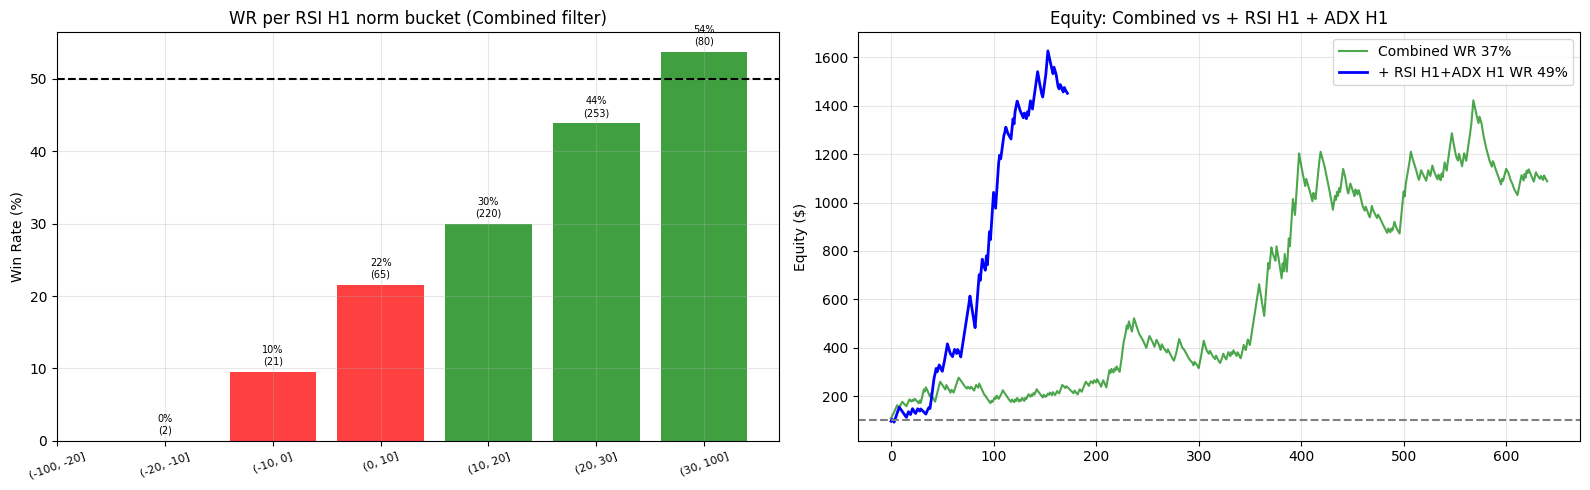

In [12]:
# Filter: RSI H1 searah trend kuat (norm > 20) + ADX H1 >= 32 (trend kuat)
# Hasil sweep: kombinasi ini memberi WR 54.3%, PF 2.38, 173 trades, streak max 12x
RSI_H1_NORM_MIN = 20
ADX_H1_MIN      = 32

t_adv = t_cf.copy()  # mulai dari Combined filter
t_adv['rsi_h1_norm'] = t_adv.apply(
    lambda x: (50 - x['rsi_h1']) if x['action']=='sell' else (x['rsi_h1'] - 50), axis=1
)

t_new = t_adv[
    (t_adv['rsi_h1_norm'] > RSI_H1_NORM_MIN) &
    (t_adv['adx_h1'] >= ADX_H1_MIN)
].copy().reset_index(drop=True)

s_new = calc_stats(t_new)

# Streak & equity
streak_n = max_streak_n = 0
for o in t_new['outcome']:
    streak_n = streak_n+1 if o=='loss' else 0
    max_streak_n = max(max_streak_n, streak_n)
eq_new    = 100 + t_new['profit'].cumsum()
min_eq_n  = eq_new.min()

print('=' * 68)
print('  FILTER LANJUTAN: Combined + RSI H1 norm>20 + ADX H1>=32')
print('=' * 68)
print(f"{'':22} {'Combined':>13} {'+ RSI H1+ADX H1':>15}")
print('-' * 68)
print(f"  {'Total Trade':<20} {s_comb['total']:>13} {s_new['total']:>15}")
print(f"  {'Win Rate':<20} {s_comb['wr']:>12.1f}% {s_new['wr']:>14.1f}%")
print(f"  {'Profit Factor':<20} ", end='')
gw = t_cf['profit'].clip(lower=0).sum()
gl = t_cf['profit'].clip(upper=0).sum()
pf_c = abs(gw/gl) if gl != 0 else 0
gw2 = t_new['profit'].clip(lower=0).sum()
gl2 = t_new['profit'].clip(upper=0).sum()
pf_n = abs(gw2/gl2) if gl2 != 0 else 0
print(f"{pf_c:>12.2f} {pf_n:>15.2f}")
print(f"  {'Net P&L':<20} ${s_comb['pl']:>12.2f} ${s_new['pl']:>14.2f}")
print(f"  {'Max Drawdown':<20} ${s_comb['dd']:>12.2f} ${s_new['dd']:>14.2f}")
print(f"  {'Equity Akhir':<20} ${s_comb['eq']:>12.2f} ${s_new['eq']:>14.2f}")
print(f"  {'Max Loss Streak':<20} {max_streak:>13}x {max_streak_n:>14}x")
print('=' * 68)
if min_eq_n <= 0:
    print(f'  STATUS: MODAL JEBOL! (equity terendah = ${min_eq_n:.2f})')
else:
    print(f'  STATUS: Modal AMAN  (equity terendah = ${min_eq_n:.2f})')

# Chart RSI H1 bucket WR
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bins = [-100, -20, -10, 0, 10, 20, 30, 100]
t_adv['rsi_h1_bucket'] = pd.cut(t_adv['rsi_h1_norm'], bins=bins)
bk = t_adv.groupby('rsi_h1_bucket', observed=False).agg(
    count=('outcome','count'),
    wr=('outcome', lambda x: (x=='profit').mean()*100)
).reset_index()
colors_bk = ['red' if str(b) in ['(-100, -20]','(-20, -10]','(-10, 0]','(0, 10]'] else 'green' for b in bk['rsi_h1_bucket']]
axes[0].bar(range(len(bk)), bk['wr'], color=colors_bk, alpha=0.75)
axes[0].axhline(50, color='black', linestyle='--')
axes[0].set_title('WR per RSI H1 norm bucket (Combined filter)')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_xticks(range(len(bk)))
axes[0].set_xticklabels([str(b) for b in bk['rsi_h1_bucket']], rotation=20, fontsize=8)
for i, row in bk.iterrows():
    if row['count'] > 0:
        axes[0].text(i, row['wr']+1, f"{row['wr']:.0f}%\n({int(row['count'])})", ha='center', fontsize=7)

# Equity comparison
eq_cf.reset_index(drop=True).plot(ax=axes[1], color='green', label=f"Combined WR {s_comb['wr']:.0f}%", linewidth=1.5, alpha=0.7)
eq_new.reset_index(drop=True).plot(ax=axes[1], color='blue', label=f"+ RSI H1+ADX H1 WR {s_new['wr']:.0f}%", linewidth=2)
axes[1].axhline(100, color='gray', linestyle='--')
axes[1].set_title('Equity: Combined vs + RSI H1 + ADX H1')
axes[1].set_ylabel('Equity ($)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. Statistik Lengkap — Evaluasi Final

In [13]:
MODAL = 100.0

def full_stats(tdf, label):
    n       = len(tdf)
    wins    = (tdf['outcome']=='profit').sum()
    losses  = (tdf['outcome']=='loss').sum()
    wr      = wins/n*100
    avg_w   = tdf[tdf['outcome']=='profit']['profit'].mean()
    avg_l   = tdf[tdf['outcome']=='loss']['profit'].mean()
    gross_w = tdf[tdf['outcome']=='profit']['profit'].sum()
    gross_l = tdf[tdf['outcome']=='loss']['profit'].sum()
    pf      = abs(gross_w/gross_l) if gross_l!=0 else 0
    net_pl  = tdf['profit'].sum()
    eq      = MODAL + tdf['profit'].reset_index(drop=True).cumsum()
    dd      = (eq - eq.cummax()).min()
    final   = eq.iloc[-1]
    jebol   = eq.min() <= 0
    streak = max_s = 0
    for o in tdf['outcome']:
        streak = streak+1 if o=='loss' else 0
        max_s  = max(max_s, streak)
    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  Total Trade      : {n}')
    print(f'  Win              : {wins} ({wr:.1f}%)')
    print(f'  Loss             : {losses} ({100-wr:.1f}%)')
    print(f'  Profit Factor    : {pf:.2f}')
    print(f'  Avg Win          : ${avg_w:.2f}')
    print(f'  Avg Loss         : ${avg_l:.2f}')
    print(f'  Gross Profit     : ${gross_w:.2f}')
    print(f'  Gross Loss       : ${gross_l:.2f}')
    print(f'  Net P&L          : ${net_pl:.2f}')
    print(f'  Modal Awal       : ${MODAL:.2f}')
    print(f'  Equity Akhir     : ${final:.2f}')
    print(f'  Return           : {(final-MODAL)/MODAL*100:.1f}%')
    print(f'  Max Drawdown     : ${dd:.2f} ({dd/MODAL*100:.1f}%)')
    print(f'  Max Loss Streak  : {max_s}x  (~${max_s*abs(avg_l):.2f} potensi loss)')
    if jebol:
        print(f'  STATUS           : MODAL JEBOL!')
    else:
        print(f'  STATUS           : Modal AMAN (min equity ${eq.min():.2f})')
    print(f'{"="*55}')

full_stats(trades_df,   'ORIGINAL  (tanpa filter)')
full_stats(t_jam,       'JAM FILTER (skip jam 10,11,16,17 UTC)')
full_stats(t_bb_filtered,'BBW FILTER (hanya BBW 1%-3%)')
full_stats(t_cf,        'COMBINED   (Jam + BBW)')
full_stats(t_new,       'ADVANCED   (Jam + BBW + RSI H1>20 + ADX H1>=32)')


  ORIGINAL  (tanpa filter)
  Total Trade      : 5336
  Win              : 1835 (34.4%)
  Loss             : 3501 (65.6%)
  Profit Factor    : 1.05
  Avg Win          : $12.42
  Avg Loss         : $-6.21
  Gross Profit     : $22791.76
  Gross Loss       : $-21751.13
  Net P&L          : $1040.63
  Modal Awal       : $100.00
  Equity Akhir     : $1140.63
  Return           : 1040.6%
  Max Drawdown     : $-1053.30 (-1053.3%)
  Max Loss Streak  : 31x  (~$192.60 potensi loss)
  STATUS           : MODAL JEBOL!

  JAM FILTER (skip jam 10,11,16,17 UTC)
  Total Trade      : 4402
  Win              : 1594 (36.2%)
  Loss             : 2808 (63.8%)
  Profit Factor    : 1.11
  Avg Win          : $12.25
  Avg Loss         : $-6.25
  Gross Profit     : $19532.26
  Gross Loss       : $-17541.80
  Net P&L          : $1990.46
  Modal Awal       : $100.00
  Equity Akhir     : $2090.46
  Return           : 1990.5%
  Max Drawdown     : $-735.99 (-736.0%)
  Max Loss Streak  : 27x  (~$168.67 potensi loss)
 

## 13. Export Trades ke CSV

In [14]:
col_order = [
    'id','signal_id','symbol','action','lot','price','sl','tp','ticket',
    'status','close_price','profit','outcome','comment','created_by','closed_at',
    'entry_target','expire_at','candle_id',
    'signal_symbol','signal','signal_sl','tp1','trend_h1',
    'ema_50_h1','ema_200_h1','in_support','in_resistance','atr_h1',
    'open_m5','high_m5','low_m5','close_m5','volume_m5',
    'ema_50_m5','ema_200_m5','rsi_m5','atr_m5',
    'has_bull_pattern','has_bear_pattern','signal_score',
    'rsi_h1','adx_h1',
    'candle_symbol','timeframe','candle_time',
    'open','high','low','close','volume',
    'body','upper_shadow','lower_shadow','candle_dir','pattern_name',
    'candle_trend_h1','candle_in_support','candle_in_resistance',
    'pattern_score','pattern_outcome',
]
out = trades_df[[c for c in col_order if c in trades_df.columns]]
out.to_csv('backtest_result_xauusd_5m.csv', index=False)
print(f'Saved {len(out)} trades | {len(out.columns)} kolom')
print('File: backtest_result_xauusd_5m.csv')
out.head(3)

Saved 5336 trades | 61 kolom
File: backtest_result_xauusd_5m.csv


,id,signal_id,symbol,action,lot,price,sl,tp,ticket,status,...,body,upper_shadow,lower_shadow,candle_dir,pattern_name,candle_trend_h1,candle_in_support,candle_in_resistance,pattern_score,pattern_outcome
0,1,1,XAUUSDm,sell,0.01,2618.30,2622.30,2610.31,None,closed,...,1.624,4.488,0.798,bullish,pin_bar_bear,down,False,False,5,profit
1,2,2,XAUUSDm,sell,0.01,2610.07,2614.43,2601.35,None,closed,...,8.258,0.389,0.462,bearish,engulfing_bear,down,False,False,5,profit
2,3,3,XAUUSDm,sell,0.01,2608.50,2612.93,2599.64,None,closed,...,1.623,3.250,0.422,bearish,pin_bar_bear,down,False,False,5,profit
